<a href="https://colab.research.google.com/github/BhavyaKansal20/RetiNex_AI/blob/main/retinex_ai_heatmap_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Device: cuda
Extracting AI Vision Brain from Multimodal Model...
✅ Heart Disease Vision Brain Loaded Successfully!


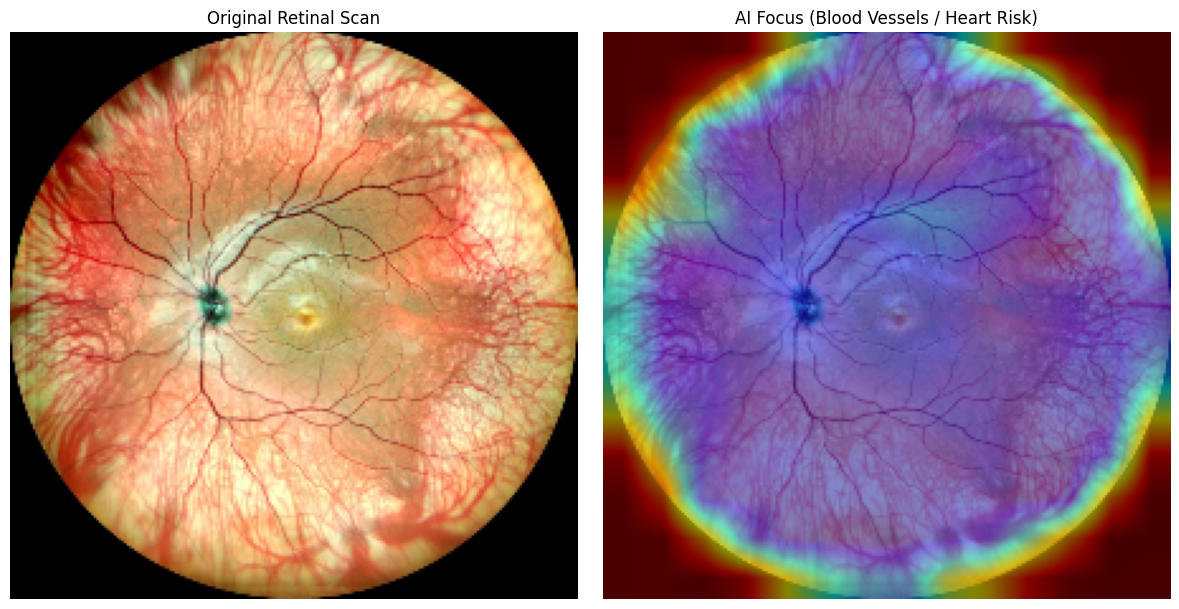

In [ ]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models
from torchvision import transforms
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

print("Extracting AI Vision Brain from Multimodal Model...")
# 1. Load exact torchvision ViT architecture
model = models.vit_b_16(pretrained=False)
model.heads = torch.nn.Identity() # Remove classification head

# 2. Load your custom trained weights
model_path = '/kaggle/input/notebooks/kansal0920/retinex-ai-training/best_sota_model.pth'
checkpoint = torch.load(model_path, map_location=device)

# Extract only the 'vit.' part of the brain
vit_weights = {}
for k, v in checkpoint.items():
    if k.startswith('vit.'):
        vit_weights[k.replace('vit.', '')] = v

model.load_state_dict(vit_weights, strict=False)
model = model.to(device)
model.eval()
print("✅ Heart Disease Vision Brain Loaded Successfully!")

# 3. Load Image
image_path = '/kaggle/input/datasets/kansal0920/my-own-retinal-eye-images/Albinotic-fundus.jpg'
img = Image.open(image_path).convert('RGB')
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = preprocess(img).unsqueeze(0).to(device)
rgb_img = cv2.resize(np.array(img), (224, 224))
rgb_img = np.float32(rgb_img) / 255

# 4. Generate Heatmap
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# Target the last layer of the Vision Transformer
target_layers = [model.encoder.layers[-1].ln_1]

# Target to maximize overall blood vessel focus
class SaliencyTarget:
    def __call__(self, model_output):
        return model_output.sum()

cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
grayscale_cam = cam(input_tensor=input_tensor, targets=[SaliencyTarget()])[0, :]
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 5. Show Result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original Retinal Scan")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("AI Focus (Blood Vessels / Heart Risk)")
plt.axis('off')

plt.tight_layout()
plt.show()